# Notebook 6 — RYS-style layer duplication on Qwen 2.5 3B

**Goal**: test Phase 5 of the project — duplicate high-value transformer blocks, measure MMLU impact.

## Two selection strategies, explicitly compared

**(A) Taylor-ranked** — pick layers purely by summed Taylor importance (let the data choose). Includes scattered individuals and a single-layer baseline (RYS found singles almost always hurt).

**(B) RYS-inspired middle band** — RYS on Qwen2-72B (80 layers) found optimal window at layers 45-51, positions 0.56-0.64. Scaled to our 36-layer Qwen 2.5 3B that's **layers 20-23** (4 contiguous). Plus a wider middle band 18-25 (8 contiguous).

**(C) Hybrid** — best contiguous 4-layer window by cumulative Taylor score. Combines RYS's 'circuits need contiguous multi-layer execution' with our data-driven scoring.

## Phase structure

1. **Phase 1 — dense + duplications**. Isolate the duplication signal on an intact model.
2. **Phase 2 — Taylor 50% pruned + duplications**. Full RMP: does duplicating high-value layers recover signal lost to pruning?

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc, time, copy
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

import config
from eval_mmlu import evaluate, print_results

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
TILE_R, TILE_C = config.TILE_SIZES[0]
PRUNE_SPARSITY = 0.50  # for Phase 2

torch.set_float32_matmul_precision("high")
print(f"torch: {torch.__version__}  device: {torch.cuda.get_device_name(0)}")
free, total = torch.cuda.mem_get_info()
print(f"GPU free: {free/1e9:.2f} / {total/1e9:.2f} GB")
assert free > 6e9, "need >6 GB free for Qwen 3B"

torch: 2.6.0+cu124  device: NVIDIA GeForce RTX 4070 Laptop GPU
GPU free: 7.65 / 8.18 GB


## 1. Load model and cache original layer list

`ORIGINAL_LAYERS` is a plain Python list of references to the 36 `Qwen2DecoderLayer` modules. Duplication = inserting the same module reference twice into `model.model.layers` (a `nn.ModuleList`). PyTorch handles shared references: same weights, two forward calls, zero extra params.

In [2]:
print(f"loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=getattr(torch, config.TORCH_DTYPE),
    device_map=config.DEVICE,
)
model.eval()

ORIGINAL_LAYERS = list(model.model.layers)
N_LAYERS = len(ORIGINAL_LAYERS)
print(f"params: {sum(p.numel() for p in model.parameters())/1e9:.2f}B, layers: {N_LAYERS}")
print(f"peak GPU: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

loading Qwen/Qwen2.5-3B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

params: 3.09B, layers: 36
peak GPU: 6.17 GB


## 2. Taylor calibration (same as notebook 5)

512 C4 samples, seq_len 128. Per-tile gradient importance via `register_post_accumulate_grad_hook` so grads never live in memory.

In [3]:
N_CAL = 512
SEQ_LEN_CAL = 128

print("loading C4 calibration stream...")
cal_ds = load_dataset(config.CALIBRATION_DATASET, config.CALIBRATION_SUBSET,
                     split="train", streaming=True, trust_remote_code=True)
cal_texts = []
for ex in cal_ds:
    t = ex.get("text", "")
    if len(t) > 50:
        cal_texts.append(t)
    if len(cal_texts) >= N_CAL:
        break
cal_encodings = [tokenizer(t, return_tensors="pt", max_length=SEQ_LEN_CAL, truncation=True)
                 for t in cal_texts]
print(f"calibration samples: {len(cal_encodings)}")

loading C4 calibration stream...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

calibration samples: 512


In [4]:
def is_mlp(name):
    return any(k in name for k in config.PRUNE_TARGETS_PATTERNS)

def get_component_type(name):
    for p in config.PRUNE_TARGETS_PATTERNS:
        if p in name:
            return p
    return "unknown"

def get_layer_idx(name):
    # e.g. 'model.layers.12.mlp.gate_proj.weight' -> 12
    parts = name.split(".")
    i = parts.index("layers")
    return int(parts[i+1])

for p in model.parameters():
    p.requires_grad_(False)
for name, p in model.named_parameters():
    if is_mlp(name) and p.ndim == 2:
        p.requires_grad_(True)

model.gradient_checkpointing_enable()
model.config.use_cache = False

importance_gpu = {}
def make_hook(pname):
    def hook(param):
        if param.grad is None:
            return
        taylor = (param.data * param.grad).abs().float()
        out_dim, in_dim = taylor.shape
        nr, nc = out_dim // TILE_R, in_dim // TILE_C
        tt = taylor[:nr*TILE_R, :nc*TILE_C].reshape(nr, TILE_R, nc, TILE_C).permute(0, 2, 1, 3)
        tile_scores = tt.reshape(nr, nc, -1).sum(dim=-1)
        if pname in importance_gpu:
            importance_gpu[pname] += tile_scores
        else:
            importance_gpu[pname] = tile_scores.clone()
        param.grad = None
    return hook

hook_handles = []
for name, p in model.named_parameters():
    if is_mlp(name) and p.ndim == 2 and p.requires_grad:
        hook_handles.append(p.register_post_accumulate_grad_hook(make_hook(name)))

print("Taylor calibration (fwd+bwd, grad_ckpt on)...")
n_samples = 0
for enc in tqdm(cal_encodings, desc="taylor"):
    model.zero_grad(set_to_none=True)
    inputs = {k: v.to(config.DEVICE) for k, v in enc.items()}
    out = model(**inputs, labels=inputs["input_ids"])
    out.loss.backward()
    n_samples += 1

for h in hook_handles:
    h.remove()
model.gradient_checkpointing_disable()
model.config.use_cache = True
for p in model.parameters():
    p.requires_grad_(False)

importance_taylor = {name: (v / n_samples).cpu().numpy() for name, v in importance_gpu.items()}
del importance_gpu
gc.collect(); torch.cuda.empty_cache()
print(f"Taylor scored {len(importance_taylor)} MLP matrices over {n_samples} samples")
print(f"peak GPU during calibration: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

Taylor calibration (fwd+bwd, grad_ckpt on)...


taylor: 100%|██████████████████████████████████████████████████████| 512/512 [03:21<00:00,  2.54it/s]


Taylor scored 108 MLP matrices over 512 samples
peak GPU during calibration: 7.01 GB


## 3. Aggregate tile scores to per-layer importance

Z-normalize per component type (same as notebook 4/5), then sum across the 3 MLP matrices per layer. Gives each layer a single Taylor score on a standardized scale.

In [5]:
# Per-component-type z-normalization
comp_stats = {}
for ct in config.PRUNE_TARGETS_PATTERNS:
    vals = np.concatenate([m.ravel() for n, m in importance_taylor.items() if ct in n])
    comp_stats[ct] = (vals.mean(), vals.std())

importance_norm = {}
for name, m in importance_taylor.items():
    mu, sd = comp_stats[get_component_type(name)]
    importance_norm[name] = (m - mu) / sd if sd > 1e-8 else np.zeros_like(m)

# Aggregate per layer: sum of normalized tile scores across the 3 MLP matrices
layer_scores = np.zeros(N_LAYERS)
for name, m in importance_norm.items():
    layer_idx = get_layer_idx(name)
    layer_scores[layer_idx] += m.sum()

# Also: sum of *raw* Taylor per layer for reference
layer_scores_raw = np.zeros(N_LAYERS)
for name, m in importance_taylor.items():
    layer_scores_raw[get_layer_idx(name)] += m.sum()

print("per-layer Taylor importance (z-normalized sum):")
for i, s in enumerate(layer_scores):
    bar = "█" * max(0, int(20 * (s - layer_scores.min()) / (layer_scores.max() - layer_scores.min())))
    print(f"  layer {i:2d}: {s:+8.1f}  {bar}")

per-layer Taylor importance (z-normalized sum):
  layer  0:   -604.2  █████████████
  layer  1: -11991.0  
  layer  2: -10675.9  █
  layer  3:  -7774.4  █████
  layer  4:  -7528.9  █████
  layer  5:  -5093.9  ████████
  layer  6:  -2515.0  ███████████
  layer  7:   -219.3  ██████████████
  layer  8:  +2255.4  ████████████████
  layer  9:  +3389.3  ██████████████████
  layer 10:  +4186.4  ███████████████████
  layer 11:  +4821.9  ████████████████████
  layer 12:  +3473.2  ██████████████████
  layer 13:  +4268.8  ███████████████████
  layer 14:  +3712.8  ██████████████████
  layer 15:  +3238.7  ██████████████████
  layer 16:  +2317.9  █████████████████
  layer 17:  +1597.7  ████████████████
  layer 18:   +697.4  ███████████████
  layer 19:    -94.3  ██████████████
  layer 20:   -293.1  █████████████
  layer 21:   -556.1  █████████████
  layer 22:   -310.7  █████████████
  layer 23:   -472.3  █████████████
  layer 24:   -736.9  █████████████
  layer 25:   -387.9  █████████████
  layer 26:

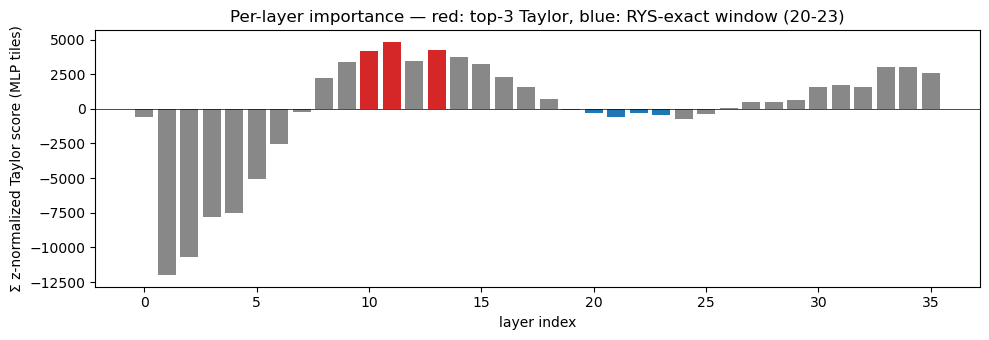

top-3 Taylor layers: [10, 11, 13]
top-1 Taylor layer:  11


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3.5))
colors = ["#888"] * N_LAYERS
# Highlight the RYS-scaled middle band and the top-3 Taylor layers
top3 = np.argsort(layer_scores)[-3:]
for i in top3:
    colors[i] = "#d62728"  # red for top-3 Taylor
for i in range(20, 24):
    if colors[i] == "#888":
        colors[i] = "#1f77b4"  # blue for RYS-exact window

ax.bar(range(N_LAYERS), layer_scores, color=colors)
ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("layer index")
ax.set_ylabel("Σ z-normalized Taylor score (MLP tiles)")
ax.set_title("Per-layer importance — red: top-3 Taylor, blue: RYS-exact window (20-23)")
plt.tight_layout(); plt.show()

print(f"top-3 Taylor layers: {sorted(top3.tolist())}")
print(f"top-1 Taylor layer:  {int(np.argmax(layer_scores))}")

## 4. Duplication utilities

Two variants of layer insertion:
- `set_duplication_range(start, end)` — RYS-style contiguous block: layers `[0..end, start..end, end+1..N-1]`. The block executes twice as a unit.
- `set_duplication_scattered(indices)` — each listed layer gets a copy inserted right after it. Tests 'scattered singles' hypothesis.
- `reset_layers()` — restore the original 36-layer stack.

In [7]:
# HF's Qwen2Model.forward uses config.layer_types[i] to pick attention mask type per layer.
# When we duplicate layers the ModuleList grows but layer_types stays at N_LAYERS -> IndexError.
# Cache the original here and mirror the same insertion transform on every dup/reset.
ORIGINAL_LAYER_TYPES = (list(model.config.layer_types)
                       if getattr(model.config, "layer_types", None) is not None else None)

def _sync_layer_types(new_types):
    if ORIGINAL_LAYER_TYPES is not None:
        model.config.layer_types = new_types

def set_duplication_range(start, end):
    """Duplicate layers [start, end] (inclusive) as a contiguous block, RYS-style."""
    new_layers = (list(ORIGINAL_LAYERS[:end+1])
                  + list(ORIGINAL_LAYERS[start:end+1])
                  + list(ORIGINAL_LAYERS[end+1:]))
    model.model.layers = nn.ModuleList(new_layers)
    model.config.num_hidden_layers = len(new_layers)
    if ORIGINAL_LAYER_TYPES is not None:
        _sync_layer_types(ORIGINAL_LAYER_TYPES[:end+1]
                          + ORIGINAL_LAYER_TYPES[start:end+1]
                          + ORIGINAL_LAYER_TYPES[end+1:])

def set_duplication_scattered(indices):
    """Duplicate each listed layer individually (insert copy right after)."""
    new_layers = list(ORIGINAL_LAYERS)
    new_types = list(ORIGINAL_LAYER_TYPES) if ORIGINAL_LAYER_TYPES is not None else None
    for idx in sorted(indices, reverse=True):
        new_layers.insert(idx + 1, ORIGINAL_LAYERS[idx])
        if new_types is not None:
            new_types.insert(idx + 1, ORIGINAL_LAYER_TYPES[idx])
    model.model.layers = nn.ModuleList(new_layers)
    model.config.num_hidden_layers = len(new_layers)
    if new_types is not None:
        _sync_layer_types(new_types)

def reset_layers():
    model.model.layers = nn.ModuleList(ORIGINAL_LAYERS)
    model.config.num_hidden_layers = len(ORIGINAL_LAYERS)
    if ORIGINAL_LAYER_TYPES is not None:
        _sync_layer_types(list(ORIGINAL_LAYER_TYPES))

# Smoke test: RYS window 20-23
set_duplication_range(20, 23)
print(f"after range dup (20-23): {len(model.model.layers)} layers, "
      f"layer_types len = {len(model.config.layer_types) if ORIGINAL_LAYER_TYPES else 'n/a'} (expect {N_LAYERS + 4})")
reset_layers()
print(f"after reset:             {len(model.model.layers)} layers (expect {N_LAYERS})")

after range dup (20-23): 40 layers, layer_types len = 40 (expect 40)
after reset:             36 layers (expect 36)


## 5. Pick variants

Selection summary:
- **A1** Taylor top-3 scattered (individual inserts at 3 different positions)
- **A2** Taylor top-1 scattered (single layer — RYS said these 'almost always hurt')
- **B1** layers 20-23 (RYS exact-scaled, 4 contiguous)
- **B2** layers 18-25 (wider middle band, 8 contiguous)
- **C** best-Taylor contiguous 4 (sliding-window max sum — RYS's circuit-coherence + data-driven)

In [8]:
def best_contiguous_window(scores, k):
    """Return (start, end) of k-layer window with highest cumulative score."""
    n = len(scores)
    best_start, best_sum = 0, -float("inf")
    for i in range(n - k + 1):
        s = float(np.sum(scores[i:i+k]))
        if s > best_sum:
            best_sum, best_start = s, i
    return best_start, best_start + k - 1

def stitched_top_n(scores, n):
    """Take top-n layers by score, return (min_idx, max_idx) to stitch as a contiguous range."""
    top_indices = sorted(np.argsort(scores)[-n:])
    return top_indices[0], top_indices[-1]

top3_layers = sorted(np.argsort(layer_scores)[-3:].tolist())
top1_layer = int(np.argmax(layer_scores))
c_start, c_end = best_contiguous_window(layer_scores, 4)
d_start, d_end = stitched_top_n(layer_scores, 5)
e_start, e_end = stitched_top_n(layer_scores, 7)
f_start, f_end = stitched_top_n(layer_scores, 9)

VARIANTS = [
    # (A) Taylor-ranked — pure importance, scattered or single
    ("A1_top3_scattered",    "scattered", top3_layers),
    ("A2_top1_single",       "scattered", [top1_layer]),
    # (B) RYS-inspired — relative-scaled middle bands
    ("B1_RYS_window_20_23",  "range",     (20, 23)),
    ("B2_wide_middle_18_25", "range",     (18, 25)),
    # (C) Hybrid — best contiguous-4 by cumulative Taylor
    ("C_best_taylor_window", "range",     (c_start, c_end)),
    # (D/E/F) Wider circuit stitches — pull in 'non-best' layers inside the top-N span
    ("D_stitched_top5",      "range",     (d_start, d_end)),
    ("E_stitched_top7",      "range",     (e_start, e_end)),
    ("F_stitched_top9",      "range",     (f_start, f_end)),
    # (G) Far-tail — second positive zone at the end. Tests decoder-like vs circuit-like behavior
    ("G_far_tail_32_35",     "range",     (32, 35)),
    # (H) Deepest trough — most-negative layers. Tests 'low importance = safe to duplicate'
    ("H_trough_1_4",         "range",     (1, 4)),
    # (I) Gap duplication — one from each functional zone, scattered to avoid circuit overlap
    ("I_gap_scatter",        "scattered", [4, 20, 32]),
]

print(f"Phase 1 and 2 variants ({len(VARIANTS)} total):")
for tag, kind, spec in VARIANTS:
    if kind == "scattered":
        extra = N_LAYERS + len(spec)
        print(f"  {tag:<24s} scattered {spec}  ({extra} total layers)")
    else:
        s, e = spec
        n_dup = e - s + 1
        print(f"  {tag:<24s} range [{s},{e}] ({n_dup} layers dup, {N_LAYERS + n_dup} total)")

Phase 1 and 2 variants (11 total):
  A1_top3_scattered        scattered [10, 11, 13]  (39 total layers)
  A2_top1_single           scattered [11]  (37 total layers)
  B1_RYS_window_20_23      range [20,23] (4 layers dup, 40 total)
  B2_wide_middle_18_25     range [18,25] (8 layers dup, 44 total)
  C_best_taylor_window     range [10,13] (4 layers dup, 40 total)
  D_stitched_top5          range [10,14] (5 layers dup, 41 total)
  E_stitched_top7          range [9,15] (7 layers dup, 43 total)
  F_stitched_top9          range [9,34] (26 layers dup, 62 total)
  G_far_tail_32_35         range [32,35] (4 layers dup, 40 total)
  H_trough_1_4             range [1,4] (4 layers dup, 40 total)
  I_gap_scatter            scattered [4, 20, 32]  (39 total layers)


In [9]:
def apply_variant(tag, kind, spec):
    reset_layers()
    if kind == "scattered":
        set_duplication_scattered(spec)
    else:
        set_duplication_range(spec[0], spec[1])

def eval_variant(tag):
    t0 = time.time()
    results = evaluate(model, tokenizer, tag=tag)
    acc = results["overall"]["accuracy"]
    print(f"  {tag:<28s} MMLU {acc*100:5.2f}%   ({time.time()-t0:.1f}s)")
    return acc, results

## 6. Phase 1 — Dense + duplications

Base model intact. Duplications only. Clean signal on 'does duplicating critical layers help?'

In [10]:
phase1_results = {}

# Dense baseline
reset_layers()
print("=== Phase 1 ===")
phase1_results["dense_baseline"], _ = eval_variant("p1_dense_baseline")

# Each variant
for tag, kind, spec in VARIANTS:
    apply_variant(tag, kind, spec)
    phase1_results[tag], _ = eval_variant(f"p1_{tag}")

reset_layers()

=== Phase 1 ===


[p1_dense_baseline] MMLU subjects: 100%|█████████████████████████████| 10/10 [01:15<00:00,  7.59s/it]


  p1_dense_baseline            MMLU 48.67%   (90.9s)


[p1_A1_top3_scattered] MMLU subjects: 100%|██████████████████████████| 10/10 [01:22<00:00,  8.24s/it]


  p1_A1_top3_scattered         MMLU 39.89%   (94.5s)


...

  p1_G_far_tail_32_35          MMLU 45.12%   (96.4s)


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/datasets/cais/mmlu/resolve/c30699e8356da336a370243923dbaf21066bb9fe/mmlu.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since cais/mmlu couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'abstract_algebra' at /home/cmoryah/.cache/huggingface/datasets/cais___mmlu/abstract_algebra/0.0.0/c30699e8356da336a370243923dbaf21066bb9fe (last modified on Thu Apr 16 10:04:40 2026).
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/datasets/cais/mmlu/resolve/c30699e8356da336a370243923dbaf21066bb9fe/mmlu.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since cais/mmlu couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'anatomy' at /home/cmoryah/.cache/huggingface/datasets/cais___mmlu/anatomy/0.0.0/c30699e8356da336a370

  p1_H_trough_1_4              MMLU 40.14%   (277.2s)


[p1_I_gap_scatter] MMLU subjects: 100%|██████████████████████████████| 10/10 [01:22<00:00,  8.23s/it]

  p1_I_gap_scatter             MMLU 40.88%   (94.3s)


## 7. Apply Taylor 50% masks (pruning for Phase 2)

Zero the bottom 50% of each MLP matrix (uniform per-matrix, Taylor-ranked). Same config as notebook 5, so we expect pre-duplication MMLU ≈ 26.68%.

In [11]:
prune_masks = {}
for name, m in importance_norm.items():
    thr = float(np.percentile(m.ravel(), PRUNE_SPARSITY * 100))
    prune_masks[name] = m < thr

mlp_linears = {}
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        pn = name + ".weight"
        if pn in prune_masks:
            mlp_linears[pn] = module

print(f"applying Taylor-50% masks to {len(mlp_linears)} MLP matrices...")
with torch.no_grad():
    for pname, module in mlp_linears.items():
        mask = prune_masks[pname]
        w = module.weight.data
        out_f, in_f = w.shape
        nr, nc = out_f // TILE_R, in_f // TILE_C
        for i in range(nr):
            for j in range(nc):
                if mask[i, j]:
                    w[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0

sample = next(iter(mlp_linears.values()))
print(f"  sample zero fraction: {100*(sample.weight.data == 0).float().mean().item():.1f}%")

applying Taylor-50% masks to 108 MLP matrices...
  sample zero fraction: 50.0%


## 8. Phase 2 — Pruned + duplications

Same 5 variants, now applied on top of Taylor-50%-pruned base. Tests 'does duplicating top circuits recover signal lost to pruning?' — the full RMP idea.

In [12]:
phase2_results = {}

reset_layers()
print("=== Phase 2 (Taylor 50% pruned base) ===")
phase2_results["pruned_baseline"], _ = eval_variant("p2_pruned_baseline")

for tag, kind, spec in VARIANTS:
    apply_variant(tag, kind, spec)
    phase2_results[tag], _ = eval_variant(f"p2_{tag}")

reset_layers()

=== Phase 2 (Taylor 50% pruned base) ===


[p2_pruned_baseline] MMLU subjects: 100%|████████████████████████████| 10/10 [01:15<00:00,  7.51s/it]


  p2_pruned_baseline           MMLU 26.68%   (87.6s)


[p2_A1_top3_scattered] MMLU subjects: 100%|██████████████████████████| 10/10 [01:21<00:00,  8.14s/it]


  p2_A1_top3_scattered         MMLU 27.51%   (94.0s)


...

  p2_G_far_tail_32_35          MMLU 27.32%   (103.9s)


[p2_H_trough_1_4] MMLU subjects: 100%|███████████████████████████████| 10/10 [01:30<00:00,  9.05s/it]


  p2_H_trough_1_4              MMLU 25.59%   (102.4s)


[p2_I_gap_scatter] MMLU subjects: 100%|██████████████████████████████| 10/10 [01:27<00:00,  8.75s/it]

  p2_I_gap_scatter             MMLU 27.07%   (101.4s)


## 9. Summary — (A) vs (B) vs (C) head to head

In [13]:
def fmt_spec(kind, spec):
    if kind == "scattered":
        return f"scattered {spec}"
    return f"range [{spec[0]},{spec[1]}] ({spec[1]-spec[0]+1} layers)"

p1_base = phase1_results["dense_baseline"]
p2_base = phase2_results["pruned_baseline"]

print("=" * 88)
print(f"  {'Variant':<28s} {'Spec':<32s} {'P1 MMLU':>9s} {'Δ P1':>7s} {'P2 MMLU':>9s} {'Δ P2':>7s}")
print("-" * 88)
print(f"  {'dense baseline':<28s} {'(no dup, no prune)':<32s} {p1_base*100:>8.2f}% {'-':>7s} {'':<9s} {'':<7s}")
print(f"  {'pruned baseline':<28s} {'(no dup, Taylor 50%)':<32s} {'':<9s} {'':<7s} {p2_base*100:>8.2f}% {'-':>7s}")
for tag, kind, spec in VARIANTS:
    p1 = phase1_results[tag]
    p2 = phase2_results[tag]
    dp1 = (p1 - p1_base) * 100
    dp2 = (p2 - p2_base) * 100
    print(f"  {tag:<28s} {fmt_spec(kind, spec):<32s} {p1*100:>8.2f}% {dp1:+6.2f}pp {p2*100:>8.2f}% {dp2:+6.2f}pp")
print("=" * 88)

  Variant                      Spec                               P1 MMLU    Δ P1   P2 MMLU    Δ P2
----------------------------------------------------------------------------------------
  dense baseline               (no dup, no prune)                  48.67%       -                  
  pruned baseline              (no dup, Taylor 50%)                                  26.68%       -
  A1_top3_scattered            scattered [10, 11, 13]              39.89%  -8.78pp    27.51%  +0.83pp
  A2_top1_single               scattered [11]                      44.82%  -3.85pp    26.33%  -0.35pp
  B1_RYS_window_20_23          range [20,23] (4 layers)            46.06%  -2.61pp    25.39%  -1.29pp
  B2_wide_middle_18_25         range [18,25] (8 layers)            45.51%  -3.16pp    27.07%  +0.39pp
  C_best_taylor_window         range [10,13] (4 layers)            43.29%  -5.38pp    26.23%  -0.45pp
  D_stitched_top5              range [10,14] (5 layers)            41.47%  -7.20pp    25.84%  -0.84pp

In [14]:
# (A) vs (B) vs (C) — grouped comparison
print("\n--- strategy comparison ---")
print("(A) Taylor-ranked scattered:")
for tag in ["A1_top3_scattered", "A2_top1_single"]:
    print(f"    {tag:<26s} P1 Δ {(phase1_results[tag]-p1_base)*100:+6.2f}pp  P2 Δ {(phase2_results[tag]-p2_base)*100:+6.2f}pp")
print("(B) RYS-inspired middle band (contiguous):")
for tag in ["B1_RYS_window_20_23", "B2_wide_middle_18_25"]:
    print(f"    {tag:<26s} P1 Δ {(phase1_results[tag]-p1_base)*100:+6.2f}pp  P2 Δ {(phase2_results[tag]-p2_base)*100:+6.2f}pp")
print("(C) Hybrid — Taylor-best contiguous 4:")
print(f"    {'C_best_taylor_window':<26s} P1 Δ {(phase1_results['C_best_taylor_window']-p1_base)*100:+6.2f}pp  P2 Δ {(phase2_results['C_best_taylor_window']-p2_base)*100:+6.2f}pp")


--- strategy comparison ---
(A) Taylor-ranked scattered:
    A1_top3_scattered          P1 Δ  -8.78pp  P2 Δ  +0.83pp
    A2_top1_single             P1 Δ  -3.85pp  P2 Δ  -0.35pp
(B) RYS-inspired middle band (contiguous):
    B1_RYS_window_20_23        P1 Δ  -2.61pp  P2 Δ  -1.29pp
    B2_wide_middle_18_25       P1 Δ  -3.16pp  P2 Δ  +0.39pp
(C) Hybrid — Taylor-best contiguous 4:
    C_best_taylor_window       P1 Δ  -5.38pp  P2 Δ  -0.45pp
